Esse Notebook será responsável por mostrar TODO meu passo a passo de evolução da acurácia, loss, quantas épocas e outras coisas 

# Primeiro teste foi feito com essa estrutura:

## Parâmetros utilizados

| Parâmetro | Valor |
|---|---:|
| Arquitetura | 784 → 128 → 64 → 10 |
| Camadas ocultas | 2 |
| Função de ativação | ReLU |
| Ativação da saída | Softmax |
| Função de erro | Cross-entropy loss |
| Otimizador | SGD |
| Learning rate | 0.1 |
| Batch size | 64 |
| Épocas | 10 |
| Seed | 42 |

## Interpretação da arquitetura

Cada imagem do MNIST possui 28 × 28 pixels. Após o reshape, cada imagem
é transformada em um vetor com 784 valores.

A arquitetura escolhida foi:

```text
784 entradas
    ↓
128 neurônios na primeira camada oculta
    ↓
64 neurônios na segunda camada oculta
    ↓
10 probabilidades de saída

```

As 10 saídas representam os dígitos possíveis entre 0 e 9.

## Resultados registrados

Os valores abaixo foram obtidos durante o treinamento do modelo
baseline.

Para cada época, foram armazenadas três informações:

- **Loss:** mede o tamanho do erro do modelo.
- **Acurácia de treino:** mede o desempenho nas imagens utilizadas
  durante o aprendizado.
- **Acurácia de teste:** mede o desempenho em imagens que não foram
  utilizadas para atualizar os pesos.

A acurácia de teste é especialmente importante porque mostra a
capacidade de generalização da rede neural.

In [ ]:
import matplotlib.pyplot as plt

epocas = [
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
]

loss = [
    0.3300,
    0.1486,
    0.1068,
    0.0833,
    0.0680,
    0.0566,
    0.0472,
    0.0405,
    0.0340,
    0.0286
]

acuracia_treino = [
    94.43,
    96.23,
    97.43,
    98.02,
    98.34,
    98.61,
    98.79,
    98.47,
    99.13,
    99.52
]

acuracia_teste = [
    94.43,
    95.60,
    96.70,
    97.37,
    97.48,
    97.50,
    97.59,
    97.05,
    97.75,
    97.94
]

## Gráfico da Acurácia 

Nessa célula foi feito o gráfico de linha para entendermos como foi a evolução por época do primeiro teste e treino. Para termos uma noção, esse teste demorou 21 segundos. Depois vamos usar esse tempo e a acurácia para entendermos mais

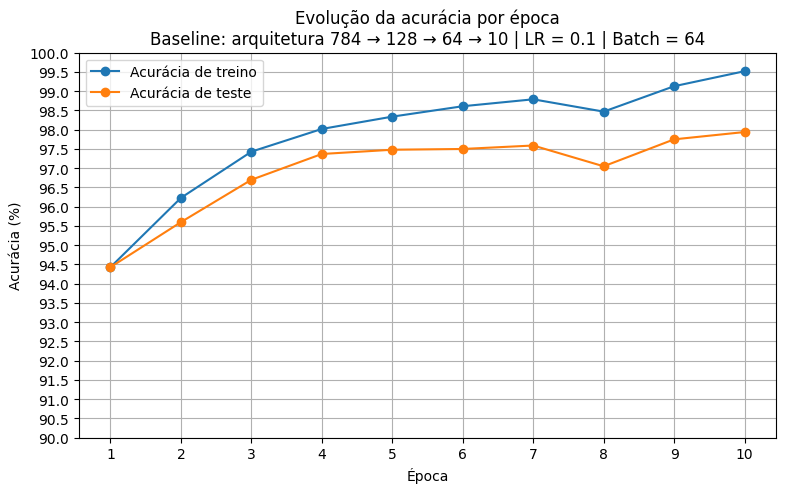

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    acuracia_treino,
    marker="o",
    label="Acurácia de treino"
)

plt.plot(
    epocas,
    acuracia_teste,
    marker="o",
    label="Acurácia de teste"
)

plt.title(
    "Evolução da acurácia por época\n"
    "Baseline: arquitetura 784 → 128 → 64 → 10 | LR = 0.1 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")

plt.xticks(epocas)

plt.ylim(90, 100)

plt.yticks(
    np.arange(90, 100.5, 0.5)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/baseline_acuracia_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Gráfico de Loss

Aqui vamos mostrar a taxa de erro do nosso projeto e da primeira medição. Como é possível ver, deu uma bela despencada da primeira para a segunda época e depois vai estabilizando. Temos que diminuir mais essa linha e esse erro. Um jeito que vejo para isso é aumentarmos ou diminuirmos a taxa de aprendizado, que será nosso próximo passo.

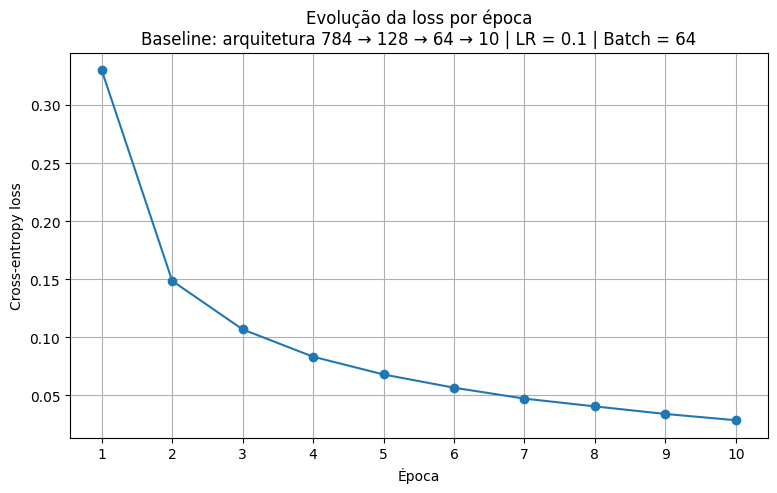

In [6]:
plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    loss,
    marker="o"
)

plt.title(
    "Evolução da loss por época\n"
    "Baseline: arquitetura 784 → 128 → 64 → 10 | LR = 0.1 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")

plt.xticks(epocas)

plt.grid(True)

plt.savefig(
    "../results/baseline_loss_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Conclusão 1

O modelo baseline apresentou uma evolução consistente durante o
treinamento.

A loss caiu de **0,3300** na primeira época para **0,0286** na décima
época. Isso indica que os ajustes realizados pelo SGD permitiram à rede
produzir previsões progressivamente mais próximas das respostas
corretas.

A acurácia de teste começou em **94,43%** e terminou em **97,94%**,
representando uma melhoria de **3,51 pontos percentuais**.

A maior acurácia de teste foi registrada na décima época: 97,94%

Houve também umas oscilações na oitava época: 
Época 7 → 97,59%
Época 8 → 97,05%
Época 9 → 97,75%

Isso é normal.


Os primeiros parâmetros foram colocados totalmente aleatórios. Para primeira vez, foi muito satisfatório. Mesmo passando de 92% de acurácia, quero deixar melhor e mais completo, tanto minha análise e testes como meu código e meu projeto. Como dito agora pouco, o primeiro parâmetro que vamos mexer é o de aprendizado.

## Segundo teste foi feito com essa estrutura:

A única alteração foi o aumento de épocas e mudando a taxa de aprendizado de 0.1 para 0.08:

| Parâmetro | Primeiro teste | Segundo teste |
|---|---:|---:|
| Arquitetura | 784 → 128 → 64 → 10 | 784 → 128 → 64 → 10 |
| Camadas ocultas | 2 | 2 |
| Função de ativação | ReLU | ReLU |
| Ativação da saída | Softmax | Softmax |
| Função de erro | Cross-entropy loss | Cross-entropy loss |
| Otimizador | SGD | SGD |
| Learning rate | 0.10 | 0.08 |
| Batch size | 64 | 64 |
| Épocas | 10 | 30 |
| Seed | 42 | 42 |
| Tempo de treinamento | 21 segundos | 1 minuto e 8 segundos |


Ganho percentual foi bem pequena: 
98,08% - 97,94% = 0,14 ponto percentual

Mas o Loss caiu demais:
0,0286 → 0,0029

Ao mesmo tempo, a acurácia de treino chegou a 100%, mas o teste ficou no máximo 98,04%. Isso sugere um começo de overfitting leve. Não é um problema grave, mas mostra que continuar aumentando épocas provavelmente trará pouco ganho real.

In [8]:
epocas_teste_2 = list(range(1, 31))

loss_teste_2 = [
    0.3667,
    0.1749,
    0.1281,
    0.1007,
    0.0833,
    0.0697,
    0.0598,
    0.0522,
    0.0448,
    0.0396,
    0.0347,
    0.0300,
    0.0264,
    0.0227,
    0.0197,
    0.0175,
    0.0146,
    0.0124,
    0.0113,
    0.0100,
    0.0085,
    0.0074,
    0.0066,
    0.0054,
    0.0047,
    0.0045,
    0.0039,
    0.0036,
    0.0031,
    0.0029
]

acuracia_treino_teste_2 = [
    93.72,
    95.26,
    96.89,
    97.57,
    97.95,
    98.21,
    98.42,
    98.58,
    98.87,
    99.23,
    99.29,
    99.37,
    99.29,
    99.13,
    99.49,
    99.60,
    99.83,
    99.68,
    99.53,
    99.80,
    99.94,
    99.88,
    99.97,
    99.98,
    99.99,
    99.99,
    100.00,
    99.99,
    99.99,
    100.00
]

acuracia_teste_teste_2 = [
    93.81,
    95.01,
    96.44,
    96.92,
    97.07,
    97.21,
    97.36,
    97.32,
    97.62,
    97.84,
    97.79,
    97.69,
    97.43,
    97.23,
    97.78,
    97.74,
    97.91,
    97.76,
    97.43,
    98.04,
    97.86,
    97.89,
    97.94,
    98.03,
    98.08,
    98.02,
    97.97,
    98.05,
    98.06,
    98.04
]

## Gráfico da acurácia

O gráfico mostra a evolução da acurácia de treino e de teste ao longo
das 30 épocas.

A acurácia de teste começou em **93,81%** e atingiu seu melhor valor na
época 25:

```text
98,08%
```

Depois disso, a acurácia permaneceu próxima desse valor, com pequenas
oscilações.

A acurácia de treino chegou a 100,00%, enquanto a acurácia de teste
ficou próxima de 98,00%.

Isso indica que a rede continuou aprendendo muito bem os dados de
treino, mas os ganhos nas imagens de teste ficaram menores após certo
ponto.

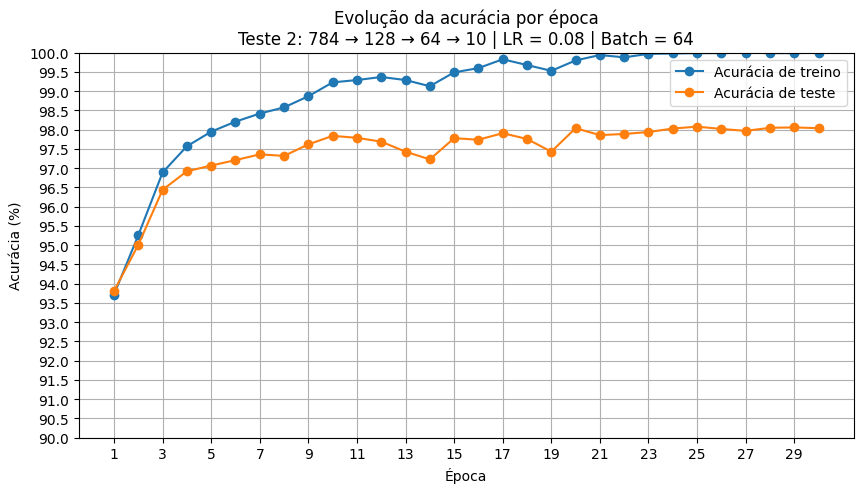

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_2,
    acuracia_treino_teste_2,
    marker="o",
    label="Acurácia de treino"
)

plt.plot(
    epocas_teste_2,
    acuracia_teste_teste_2,
    marker="o",
    label="Acurácia de teste"
)

plt.title(
    "Evolução da acurácia por época\n"
    "Teste 2: 784 → 128 → 64 → 10 | LR = 0.08 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")

plt.xticks(
    range(1, 31, 2)
)

plt.ylim(
    90,
    100
)

plt.yticks(
    np.arange(90, 100.5, 0.5)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/teste_2_acuracia_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

# Gráfico de loss

A loss caiu de **0,3667** na primeira época para **0,0029** na trigésima
época.

A queda foi mais intensa nas primeiras épocas e ficou mais gradual ao
longo do treinamento.

Esse comportamento mostra que a rede aprendeu rapidamente os padrões
mais importantes e depois passou a realizar ajustes menores.

Mesmo quando a acurácia de teste começou a oscilar perto de 98%, a loss
continuou diminuindo. Isso mostra que o modelo ficou mais confiante nas
respostas corretas, mesmo sem aumentar muito a quantidade total de
acertos.

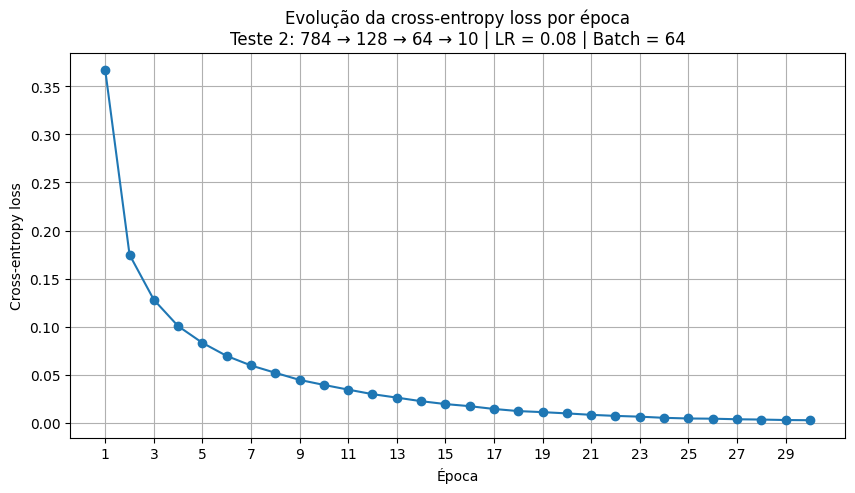

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    epocas_teste_2,
    loss_teste_2,
    marker="o"
)

plt.title(
    "Evolução da cross-entropy loss por época\n"
    "Teste 2: 784 → 128 → 64 → 10 | LR = 0.08 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")

plt.xticks(
    range(1, 31, 2)
)

plt.grid(True)

plt.savefig(
    "../results/teste_2_loss_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Conclusão 2

No segundo teste, o learning rate foi reduzido de **0.10** para **0.08**
e a quantidade de épocas foi aumentada de **10** para **30**.

O treinamento demorou aproximadamente **1 minuto e 8 segundos**.

A melhor acurácia de teste foi registrada na época 25:

```text
98,08%
```

A acurácia final foi 98,04%. Comparando com o baseline, houve um ganho máximo de 98,08% - 97,94% = 0,14 ponto percentual.

A loss caiu de 0,0286 no final do baseline para 0,0029 no final
do segundo experimento.

Essa queda mostra que o modelo ficou mais confiante em suas previsões.

Por outro lado, a acurácia de treino atingiu 100,00%, enquanto a
acurácia de teste permaneceu próxima de 98,00%. Isso sugere um leve
início de overfitting.

O aumento de épocas trouxe uma melhora pequena na acurácia de teste,
mas aumentou consideravelmente o tempo de treinamento.

Por isso, vou alterar um parâmetro por vez para entender melhor. Vou voltar um passo e diminuir para 20 épocas para ver o resultado, mesmo que de para ver muito claro no gráfico que é a partir daí que começa os 100% nos treinamentos. 